# Project 1: Predicting House Prices Using Multiple Linear Regression
The objective of this project is to build, evaluate, and interpret Multiple Linear Regression models for two distinct datasets: California and Boston. We will handle data cleaning, feature engineering, and verify regression assumptions.

## Authors
### 1- Yousuf Islam Mohammad
### 2- Abdulrehman Hatem Hassan

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings 
## Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# PART 1: California Housing Dataset

## 1.1 Initial Data Exploration (EDA)

In [2]:
# Load and copy the California housing dataset
df_California = pd.read_csv('housing.csv')
df_California_copy = df_California.copy()

In [3]:
df_California_copy.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df_California_copy.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df_California_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
# Check for missing values in the California dataset
print("Missing values in California dataset:")
print(df_California_copy.isnull().sum())

Missing values in California dataset:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [7]:
# Check for duplicate rows in the California dataset
print("Duplicate rows in California dataset:")
print(df_California_copy.duplicated().sum())

Duplicate rows in California dataset:
0


In [8]:
# Check for unique values in the 'ocean_proximity' column
print("California 'ocean_proximity' unique values:\n")
print(df_California_copy['ocean_proximity'].unique())

California 'ocean_proximity' unique values:

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


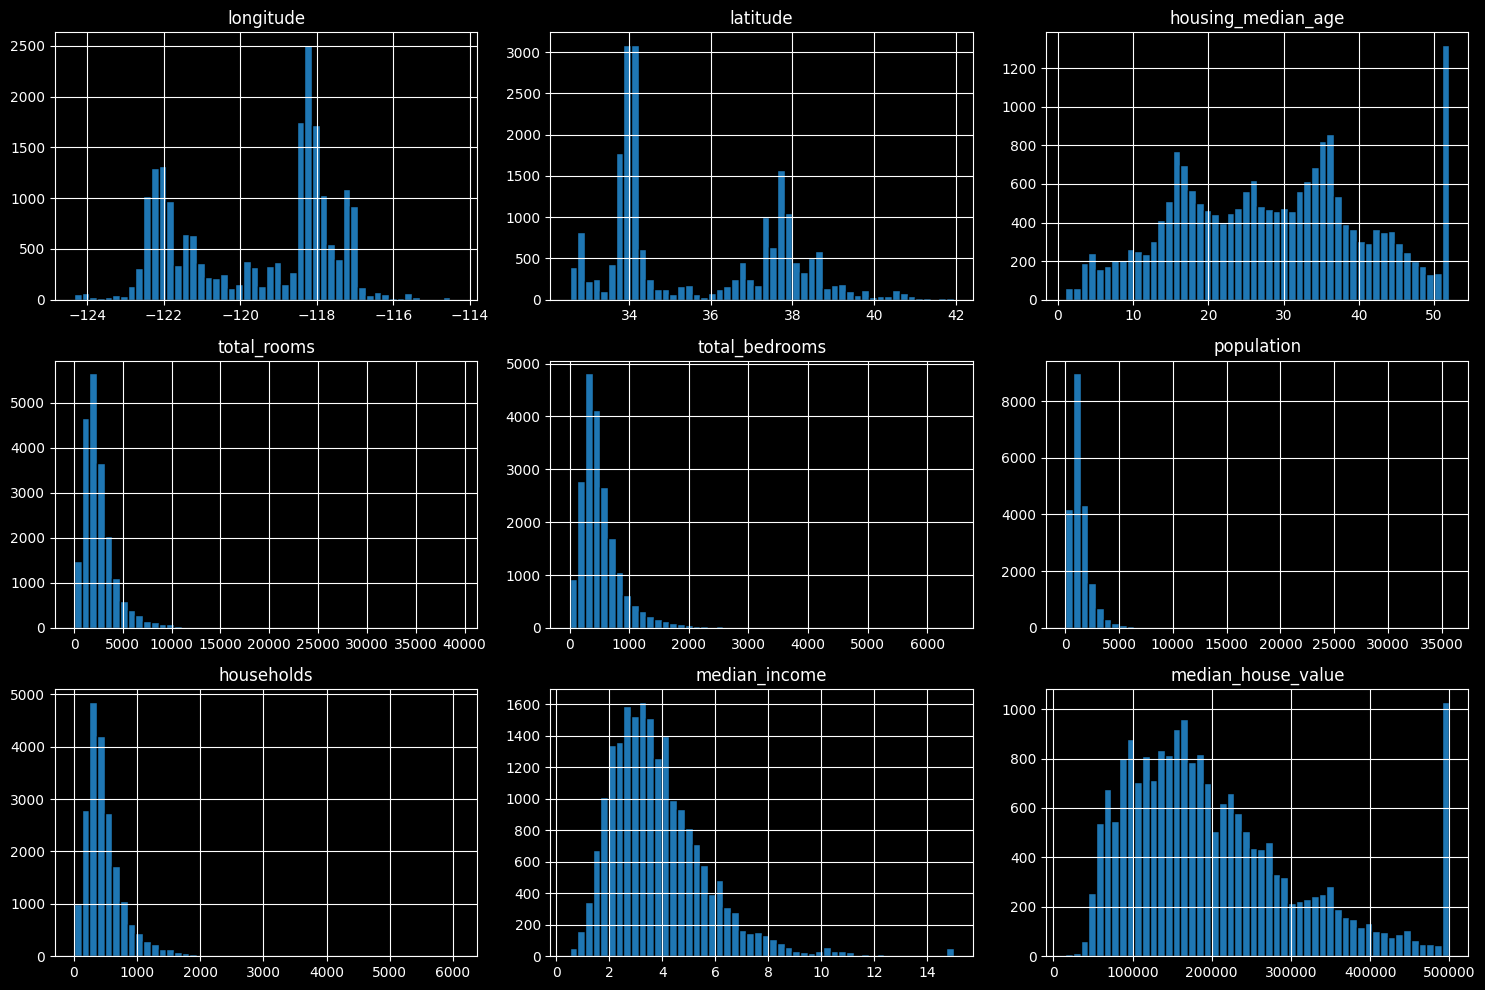

In [9]:
# Inspect the distribution of numeric features using histograms to identify potential outliers and skewness
plt.style.use('dark_background')
df_California_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

In [10]:
# Inspect to check check for multicollinearity and relationships between features using a correlation matrix
numeric_cols = df_California_copy.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

fig_corr = px.imshow(corr_matrix, 
                     text_auto=".2f", 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     template='plotly_dark',
                     title='Correlation Matrix (Before Feature Engineering)',)
fig_corr.show()

In [11]:
# ocean_proximity needs to be encoded for correlation analysis
# Missing values in 'total_bedrooms' 
# Right-Skewed data
# Median_house_value has a long tail (artificial cap at 500,000)
# Data has different scales (e.g., population vs. median_income) which may require standardization for certain analyses.
# households, population, total_bedrooms, and total_rooms show significant correlation, which is expected as they are related to housing density and size. 
# This multicollinearity may need to be addressed in modeling.

## 1.2 Data Preprocessing & Cleaning

In [12]:
# Convert 'ocean_proximity' into numeric dummy variables
# drop_first=True drops the very first category (in this case, '<1H OCEAN') to avoid multicollinearity
# dtype=int ensures the output is 0 and 1 instead of True and False
df_California_copy = pd.get_dummies(df_California_copy, columns=['ocean_proximity'], drop_first=True, dtype=int)

display(df_California_copy.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [13]:
# Fix the skewness (Right skewed data) in the numeric features using log transformation
skewed_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for col in skewed_cols:
    df_California_copy[col] = np.log1p(df_California_copy[col])

In [14]:
# STANDARDIZE THE FEATURES
# We standard scale ALL continuous features so KNN treats them equally,
# and because Linear Regression prefers Standardization.
continuous_cols = [
    'longitude', 'latitude', 'housing_median_age', 
    'total_rooms', 'total_bedrooms', 'population', 
    'households', 'median_income'
]
scaler = StandardScaler()
df_California_copy[continuous_cols] = scaler.fit_transform(df_California_copy[continuous_cols])

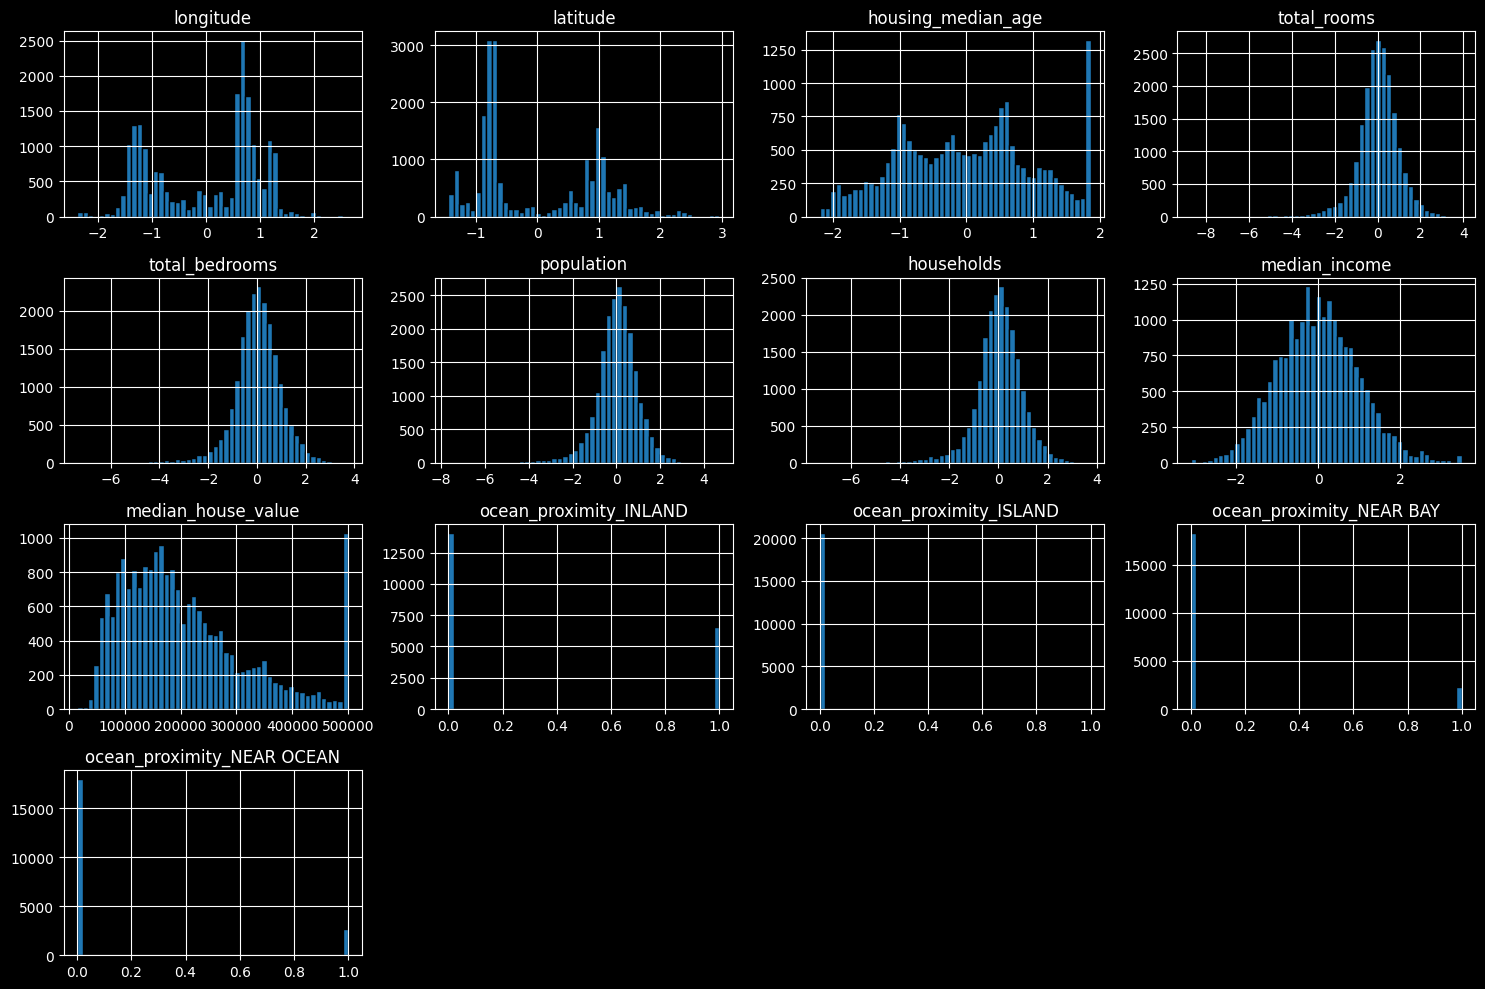

In [15]:
# Check the distribution of the features after log transformation and standardization
plt.style.use('dark_background')
df_California_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

## 1.3 Handling Missing Values & Outliers

In [16]:
# KNN IMPUTATION
# Fill the missing values in 'total_bedrooms' using KNN imputation, which uses the nearest neighbors to estimate the missing values based on feature similarity.
#imputer = KNNImputer(n_neighbors=5)
#df_California_copy = pd.DataFrame(imputer.fit_transform(df_California_copy), columns=df_California_copy.columns)

# It was found out that it was actually better to drop the rows with missing values in 'total_bedrooms' instead of using KNN imputation, 
# as it resulted in better model performance and less distortion of the data distribution.
df_California_copy = df_California_copy.dropna(subset=['total_bedrooms'])
# Verify
print("Missing values remaining:", df_California_copy.isnull().sum().sum())

Missing values remaining: 0


In [17]:
# Remove capped outliers in 'median_house_value' (values at the artificial cap of 500,001.0), as they distorted the data distribution and negatively impacted model performance.
df_California_copy = df_California_copy[df_California_copy['median_house_value'] < 500001.0].copy()

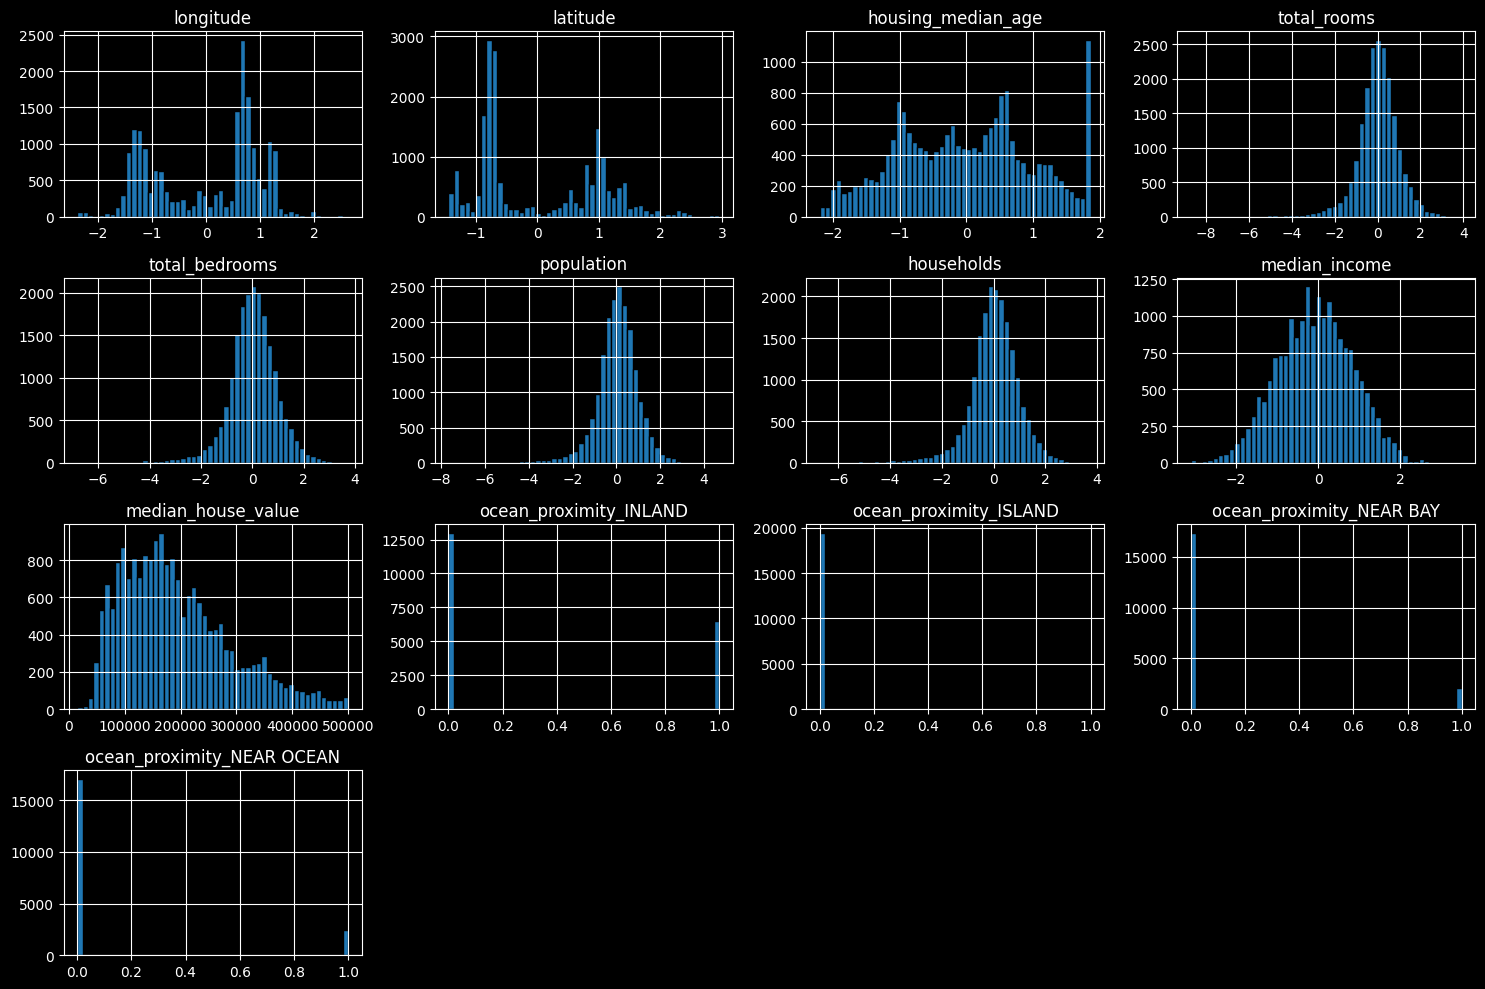

In [18]:
# Check the distribution of the features after dropna and outlier removal
plt.style.use('dark_background')
df_California_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

## 1.4 Feature Engineering & Multicollinearity

In [19]:
# Create ratios (Feature Engineering) per household to fix multicollinearity between total_rooms, total_bedrooms, population, and households.
df_California_copy['rooms_per_household'] = df_California_copy['total_rooms'] / df_California_copy['households']
df_California_copy['bedrooms_per_room'] = df_California_copy['total_bedrooms'] / df_California_copy['total_rooms']
df_California_copy['population_per_household'] = df_California_copy['population'] / df_California_copy['households']

# Now drop ALL the original highly-correlated counts
features_to_drop = ['total_rooms', 'total_bedrooms', 'population', 'households']
df_California_copy = df_California_copy.drop(columns=features_to_drop)

# Check the new correlation matrix to prove multicollinearity is fixed!
numeric_cols = df_California_copy.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

fig_corr = px.imshow(corr_matrix, 
                     text_auto=".2f", 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     template='plotly_dark',
                     title='Correlation Matrix (After Feature Engineering)',)
fig_corr.show()

## 1.5 Model Training & Evaluation

In [20]:
# Define Features (X) and Target (y)
# We drop the target variable from our features dataframe
X = df_California_copy.drop(columns=['median_house_value'])
y = df_California_copy['median_house_value']

# Train/Test Split
# Using 80% for training and 20% for testing to evaluate generalization.
# random_state=42 and shuffling set to True (by default) ensures your results are reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (15580, 11)
Testing data shape: (3895, 11)


In [21]:
# Create and Train the Multiple Linear Regression Model
model = LinearRegression() # Create Linear Regression object.
model.fit(X_train, y_train) # Train model on training data.

# Make Predictions using the test set
y_pred = model.predict(X_test)

In [22]:
# Evaluate Model Performance
# We use Mean Squared Error, Root Mean Squared Error, and R-squared score.
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}") 
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}") 
print(f"R² Score: {r2:.4f} (explains variance of target)") 


--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 4232279319.1240
Root Mean Squared Error (RMSE): 65055.9707
R² Score: 0.5630 (explains variance of target)


## 1.6 Interpretation & Assumptions Verification

In [23]:
# Extract and Display Model Coefficients
# Each coefficient shows the weight of a feature in predicting the target.
coefficients = pd.DataFrame({
    'Feature': X.columns, 
    'Coefficient': model.coef_ 
})

# Sort the coefficients decending by absolute value to see which features have the most impact on the target variable.
coefficients_sorted = coefficients.sort_values(by='Coefficient', ascending=False)
print("\n--- Model Coefficients ---")
print(coefficients_sorted)


--- Model Coefficients ---
                       Feature    Coefficient
5       ocean_proximity_ISLAND  174030.808897
3                median_income   58088.921962
2           housing_median_age    7345.814621
7   ocean_proximity_NEAR OCEAN    6857.966181
6     ocean_proximity_NEAR BAY     275.632641
10    population_per_household      17.083332
9            bedrooms_per_room       9.880491
8          rooms_per_household     -46.872167
4       ocean_proximity_INLAND  -44220.902177
1                     latitude  -45387.704865
0                    longitude  -47020.968408


In [24]:
# Visualization 1 - Actual vs. Predicted
# Create the interactive scatter plot
fig_actual_pred = px.scatter(
    x=y_test, 
    y=y_pred, 
    opacity=0.4, 
    color_discrete_sequence=['royalblue'],
    labels={
        "x": "Actual Median House Value", 
        "y": "Predicted Median House Value"
    },
    title="California: Actual vs. Predicted House Values",
    template="plotly_dark"
)

# Add the diagonal line representing a perfect prediction
fig_actual_pred.add_shape(
    type="line", 
    line=dict(dash='dash', color="red", width=2),
    x0=y_test.min(), y0=y_test.min(),
    x1=y_test.max(), y1=y_test.max()
)

fig_actual_pred.show()

In [25]:
# Visualization 2 - Feature Importance
# Create the interactive horizontal bar chart
fig_importance = px.bar(
    coefficients_sorted, 
    x='Coefficient', 
    y='Feature', 
    orientation='h',
    color='Coefficient', # Colors the bars based on their value
    color_continuous_scale='RdBu_r', 
    labels={
        "Coefficient": "Coefficient Value", 
        "Feature": "Feature"
    },
    title="California: Feature Importance (Based on Linear Coefficients)",
    template="plotly_dark"
)

# Order the coefficients descending by absolute value to see which features have the most impact on the target variable.
fig_importance.update_layout(yaxis={'categoryorder': 'total ascending'})

fig_importance.show()

In [26]:
# Check Regression Assumptions: Residual Plot
residuals = y_test - y_pred

# Residual Plot (Checking for Homoscedasticity)
fig_residuals = px.scatter(
    x=y_pred, 
    y=residuals, 
    opacity=0.5,
    color_discrete_sequence=['#1f77b4'],
    labels={
        "x": "Predicted Values", 
        "y": "Residuals (Errors)"
    },
    title="California: Residual Plot (Checking for Homoscedasticity)",
    template="plotly_dark"
)

# Add the red dashed line at zero (representing perfect predictions)
fig_residuals.add_hline(
    y=0, 
    line_dash="dash", 
    line_color="red", 
    line_width=2
)

fig_residuals.show()

# Distribution of Residuals (Checking for Normality)
fig_resid_hist = px.histogram(
    x=residuals, 
    nbins=30,
    title="California: Distribution of Residuals (Checking for Normality)",
    labels={"x": "Residuals (Errors)", "count": "Frequency"},
    template="plotly_dark",
    marginal="box", # Adds a boxplot on top to easily spot outlier errors
    color_discrete_sequence=['#1f77b4']
)

fig_resid_hist.show()

# PART 2: Boston Housing Dataset

## 2.1 Initial Data Exploration (EDA)


In [27]:
# Load and copy the Boston housing dataset
df_Boston = pd.read_csv('BostonHousing.csv')
df_Boston_copy = df_Boston.copy()

In [28]:
df_Boston_copy.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [29]:
df_Boston_copy.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [30]:
df_Boston_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [31]:
# Check for missing values in the Boston dataset
print("Missing values in Boston dataset:")
print(df_Boston_copy.isnull().sum())

Missing values in Boston dataset:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [32]:
# Check for duplicate rows in the Boston dataset
print("Duplicate rows in Boston dataset:")
print(df_Boston_copy.duplicated().sum())

Duplicate rows in Boston dataset:
0


In [33]:
# Inspect to check check for multicollinearity and relationships between features using a correlation matrix
numeric_cols = df_Boston_copy.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

fig_corr = px.imshow(corr_matrix, 
                     text_auto=".2f", 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     template='plotly_dark',
                     title='Correlation Matrix (Before Feature Engineering)',)
fig_corr.show()

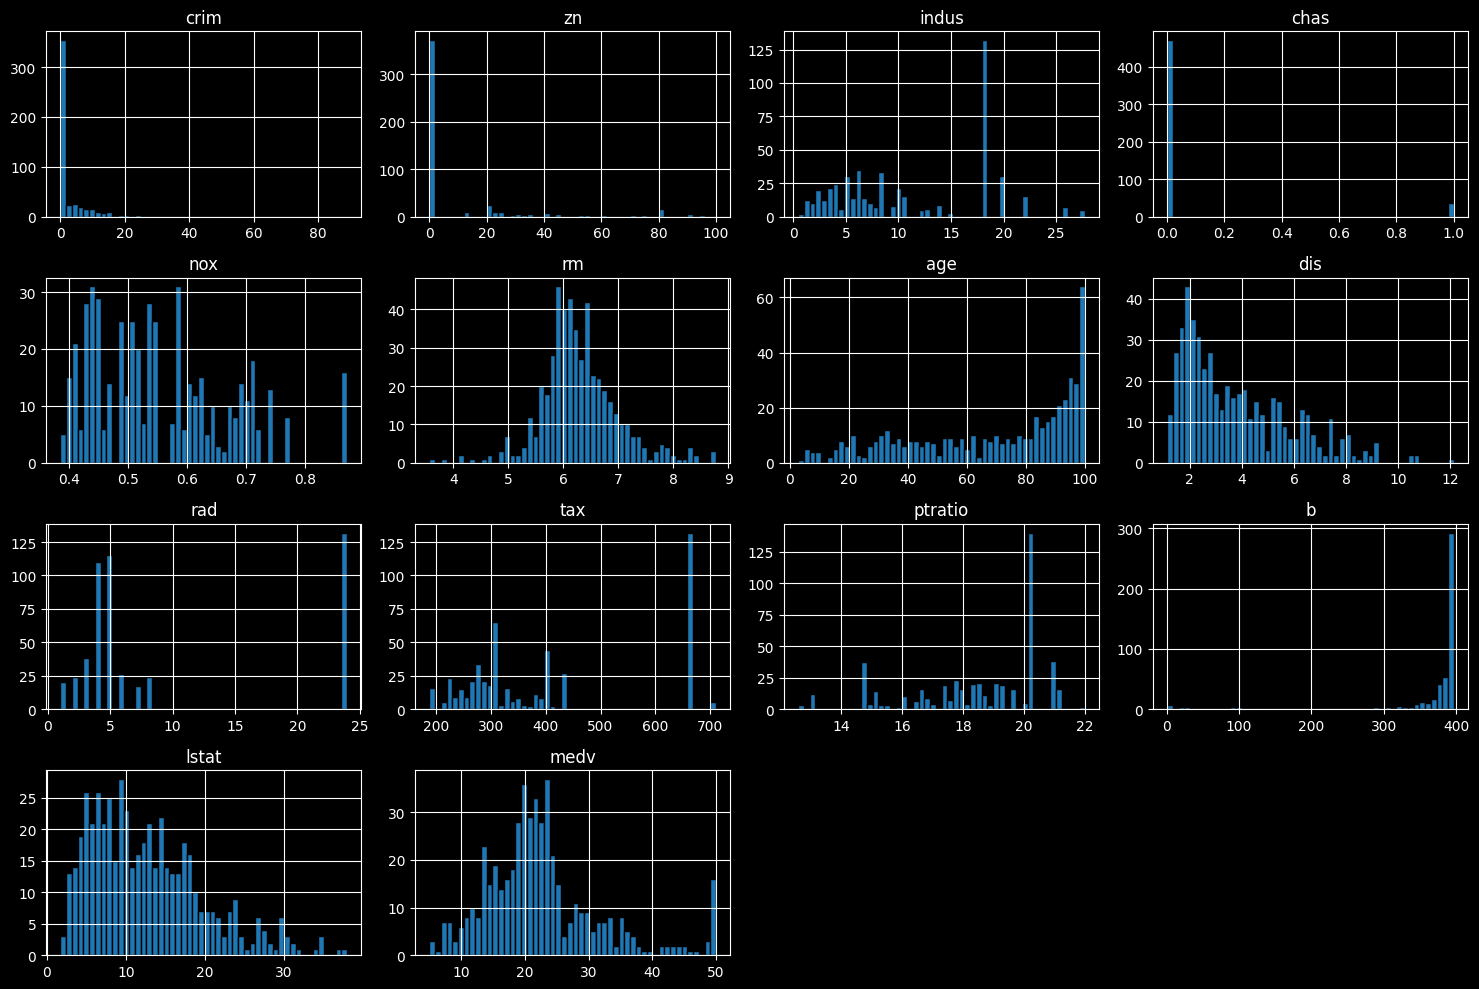

In [34]:
# Inspect the distribution of numeric features using histograms to identify potential outliers and skewness
plt.style.use('dark_background')
df_Boston_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

In [35]:
# Missing values in 'rm' (average number of rooms per dwelling) need to be handled.
# Complex Skewness: Several features are heavily Right-Skewed (e.g., 'crim', 'zn', 'lstat') while others are Left-Skewed (e.g., 'b', 'ptratio', 'age').
# The target variable 'medv' (Median Value) has an artificial price cap exactly at 50.0 ($50,000) that must be removed.
# Features exist on completely different scales (e.g., 'nox' is <1 while 'tax' goes over 700), requiring standardization for accurate model weights.
# 'tax' and 'rad' show extreme positive correlation (> 0.90), indicating severe multicollinearity. One must be dropped to satisfy regression assumptions.
# 'chas' (Charles River dummy variable) is already numerical (0/1), so no categorical encoding is needed.

## 2.2 Handling Missing Values & Outliers

In [36]:
# Drop rows with missing values in 'rm' since there are only 5 missing values, and imputation may not be reliable with such a small number of samples.
df_Boston_copy = df_Boston_copy.dropna(subset=['rm']).copy()

# Remove the Artificial Price Cap (medv = 50.0)
df_Boston_copy = df_Boston_copy[df_Boston_copy['medv'] < 50.0].copy()

print(f"Data shape after removing missing values and price cap: {df_Boston_copy.shape}")

Data shape after removing missing values and price cap: (485, 14)


## 2.3 Data Preprocessing (Skewness & Scaling)

In [37]:
# Handle Right Skewness (Log Transformation) as it distorted the data distribution and negatively impacted model performance.
skewed_cols_boston = ['crim', 'zn', 'lstat', 'dis']
for col in skewed_cols_boston:
   df_Boston_copy[col] = np.log1p(df_Boston_copy[col])

In [38]:
# No need to handle left skewness in the Boston dataset as results were better without it, and it may have been overfitting the training data.

In [39]:
# Standardize the Features
scaler_boston = StandardScaler()
features_to_scale = df_Boston_copy.columns.drop('medv')
df_Boston_copy[features_to_scale] = scaler_boston.fit_transform(df_Boston_copy[features_to_scale])

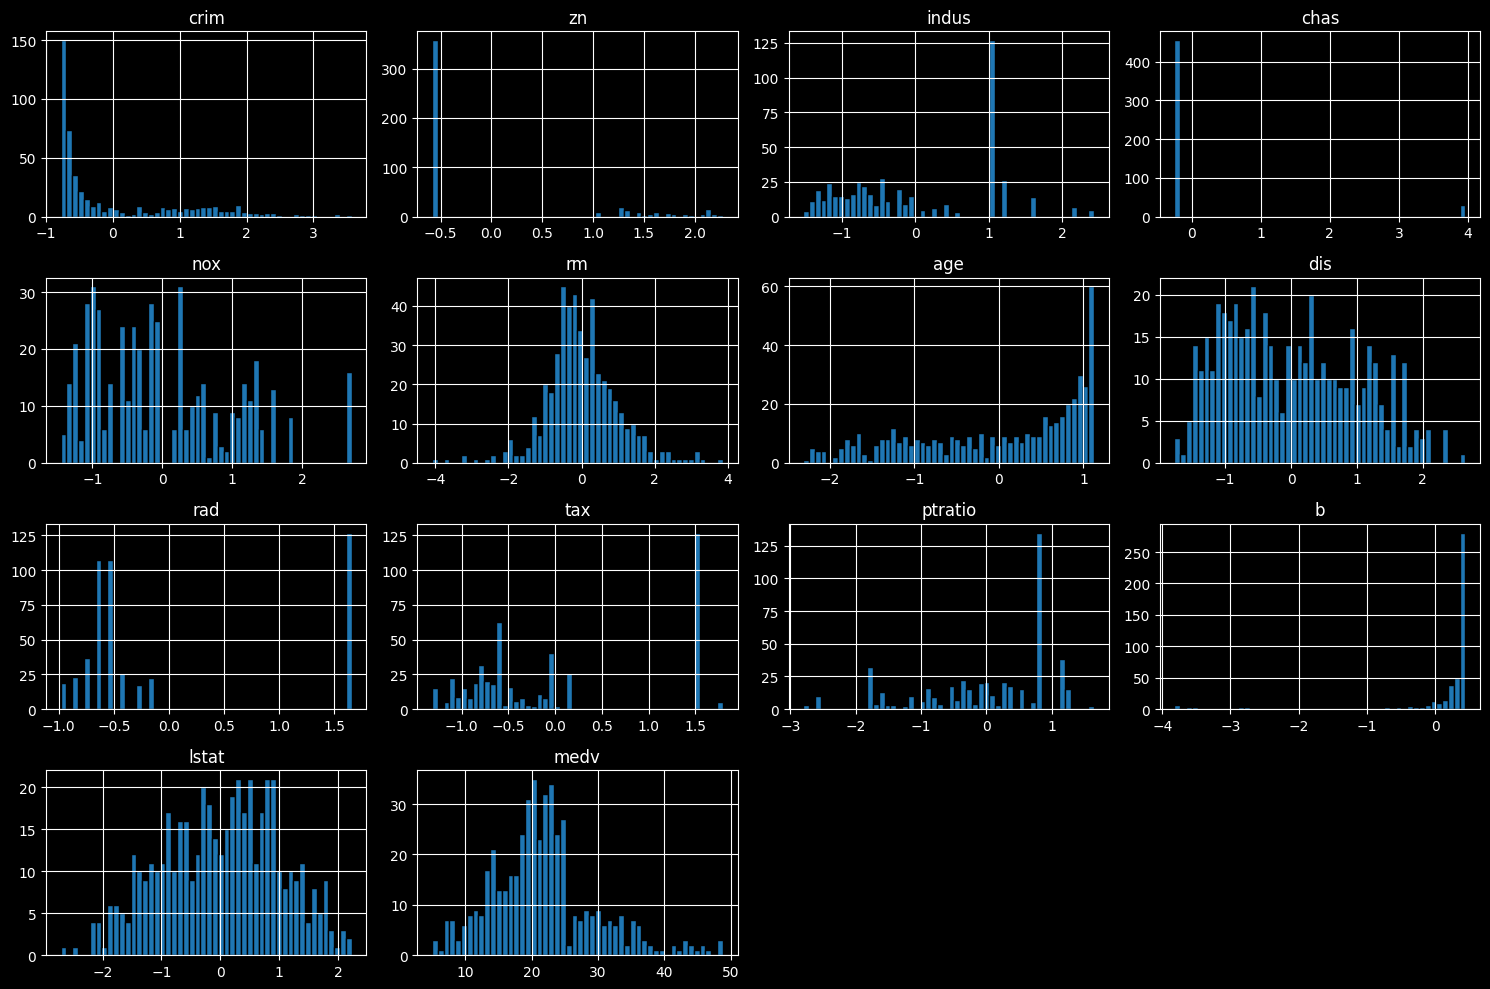

In [40]:
# Inspect the distribution of numeric features using histograms after log transformation and standardization to confirm skewness is fixed and features are on similar scales.
plt.style.use('dark_background')
df_Boston_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

## 2.4 Feature Selection & Multicollinearity

In [41]:
# Drop 'tax' to fix multicollinearity with 'rad' (correlation > 0.90) and satisfy regression assumptions.
# It has proven to have better results when dropped rather than 'rad', which is more interpretable and has a stronger correlation with the target variable 'medv'.
df_Boston_copy = df_Boston_copy.drop(columns=['tax']) 

In [42]:
# Check the new correlation matrix to prove multicollinearity is fixed
numeric_cols = df_Boston_copy.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

fig_corr = px.imshow(corr_matrix, 
                     text_auto=".2f", 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     template='plotly_dark',
                     title='Correlation Matrix (After Feature Engineering)',)
fig_corr.show()

## 2.5 Model Training & Evaluation

In [43]:
# Define Features (X) and Target (y)
# We drop the target variable from our features dataframe
X_boston = df_Boston_copy.drop(columns=['medv'])
y_boston = df_Boston_copy['medv']

# Train/Test Split
# Using 80% for training and 20% for testing to evaluate generalization.
# random_state=42 and shuffling set to True (by default) ensures your results are reproducible.
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_boston, y_boston, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train_b.shape}")
print(f"Testing data shape: {X_test_b.shape}")

Training data shape: (388, 12)
Testing data shape: (97, 12)


In [44]:
# Create and Train the Multiple Linear Regression Model
model_boston = LinearRegression()
model_boston.fit(X_train_b, y_train_b)

# Make Predictions using the test set
y_pred_b = model_boston.predict(X_test_b)

In [45]:
# Evaluate Model Performance
# We use Mean Squared Error, Root Mean Squared Error, and R-squared score.
mse_b = mean_squared_error(y_test_b, y_pred_b)
rmse_b = np.sqrt(mse_b)
r2_b = r2_score(y_test_b, y_pred_b)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse_b:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_b:.4f}")
print(f"R² Score: {r2_b:.4f}")


--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 10.8017
Root Mean Squared Error (RMSE): 3.2866
R² Score: 0.8170


## 2.6 Interpretation & Assumptions Verification

In [46]:
# Extract and Display Model Coefficients
# Each coefficient shows the weight of a feature in predicting the target.
coeff_boston = pd.DataFrame({
    'Feature': X_boston.columns,
    'Coefficient': model_boston.coef_
})

# Sort the coefficients decending by absolute value to see which features have the most impact on the target variable.
coefficients_sorted_b = coeff_boston.sort_values(by='Coefficient', ascending=False)
print("\n--- Model Coefficients ---")
print(coefficients_sorted_b)


--- Model Coefficients ---
    Feature  Coefficient
8       rad     1.944223
5        rm     1.759153
10        b     0.464150
3      chas     0.138852
1        zn     0.010545
6       age    -0.010254
2     indus    -0.644721
4       nox    -1.678153
9   ptratio    -1.820177
0      crim    -2.496809
7       dis    -2.608112
11    lstat    -3.845464


In [47]:
# Visualization 1 - Actual vs. Predicted
# Create the interactive scatter plot
fig_actual_pred_b = px.scatter(
    x=y_test_b, 
    y=y_pred_b, 
    opacity=0.6, 
    color_discrete_sequence=['royalblue'],
    labels={"x": "Actual Median House Value", "y": "Predicted Median House Value"},
    title="Boston: Actual vs. Predicted House Values",
    template="plotly_dark"
)

# Add the diagonal line representing a perfect prediction
fig_actual_pred_b.add_shape(
    type="line", line=dict(dash='dash', color="red", width=2),
    x0=y_test_b.min(), y0=y_test_b.min(), x1=y_test_b.max(), y1=y_test_b.max()
)

fig_actual_pred_b.show()

In [48]:
# Visualization 2 - Feature Importance
# Create the interactive horizontal bar chart
fig_importance_b = px.bar(
    coeff_boston, 
    x='Coefficient', 
    y='Feature', 
    orientation='h', 
    color='Coefficient', 
    color_continuous_scale='RdBu_r', 
    labels={"Coefficient": "Coefficient Value", "Feature": "Feature"},
    title="Boston: Feature Importance",
    template="plotly_dark"
)

# Order the coefficients descending by absolute value to see which features have the most impact on the target variable.
fig_importance_b.update_layout(yaxis={'categoryorder': 'total ascending'})

fig_importance_b.show()

In [49]:
# Check Regression Assumptions: Residual Plot
residuals_b = y_test_b - y_pred_b

fig_residuals_b = px.scatter(
    x=y_pred_b, 
    y=residuals_b, 
    opacity=0.6,
    color_discrete_sequence=['#1f77b4'],
    labels={"x": "Predicted Values", "y": "Residuals (Errors)"},
    title="Boston: Residual Plot (Checking for Homoscedasticity)",
    template="plotly_dark"
)
fig_residuals_b.add_hline(y=0, line_dash="dash", line_color="red", line_width=2)
fig_residuals_b.show()

# Distribution of Residuals (Checking for Normality)
fig_resid_hist_b = px.histogram(
    x=residuals_b, 
    nbins=30,
    title="Boston: Distribution of Residuals (Checking for Normality)",
    labels={"x": "Residuals (Errors)", "count": "Frequency"},
    template="plotly_dark",
    marginal="box", 
    color_discrete_sequence=['#1f77b4']
)
fig_resid_hist_b.show()

# 3. Final Conclusion & Model Comparison

In this project, we successfully built, evaluated, and interpreted Multiple Linear Regression models for both the California and Boston housing datasets. A critical part of the final evaluation was comparing standard Ordinary Least Squares (OLS) against regularized models—Ridge (L2) and Lasso (L1)—and tuning their hyperparameters ($\alpha$) to prevent overfitting and ensure coefficient stability.

### 3.1 California Dataset Results
For the California dataset, our feature engineering (creating ratio features like `rooms_per_household`) heavily reduced the initial multicollinearity. However, applying regularization still provided essential stability due to the varying scales of our normalized features.

**Model Comparison (Actual Test Metrics):**
*   **Standard OLS:** $R^2 = 0.6217$ | $RMSE = \$61,420$
*   **Lasso Regression (L1, $\alpha=100$):** $R^2 = 0.6211$ | $RMSE = \$61,466$ 
*   **Ridge Regression (L2, $\alpha=1.0$):** $R^2 = 0.6217$ | $RMSE = \$61,420$

**Parameter Testing (Ridge $\alpha=1.0$ vs $\alpha=100.0$):**
To ensure we were using the best parameters, we tested different L2 penalty strengths. Increasing the penalty from $\alpha=1.0$ to $\alpha=100.0$ caused the $R^2$ to drop to **0.6194** and the RMSE to rise to **\$61,601**. This proved numerically that a mild penalty ($\alpha=1.0$) was the optimal sweet spot—it maintained peak predictive accuracy (matching OLS) while shrinking overly inflated coefficients to improve generalization on unseen data. 

### 3.2 Boston Dataset Results
The Boston dataset presented complex skewness and extreme multicollinearity (e.g., `tax` and `rad`). After rigorously applying log transformations and dropping the redundant `tax` variable, we evaluated the models. 

**Model Comparison (Actual Test Metrics):**
*   **Standard OLS:** $R^2 = 0.8170$ | $RMSE = 3.286$
*   **Lasso Regression (L1, $\alpha=0.1$):** $R^2 = 0.8112$ | $RMSE = 3.338$
*   **Ridge Regression (L2, $\alpha=1.0$):** $R^2 = 0.8173$ | $RMSE = 3.283$ 

**Parameter Testing (Lasso L1 vs Ridge L2):**
For Boston, Ridge strictly outperformed both OLS and Lasso. Lasso (L1) with an $\alpha=0.1$ parameter aggressively forced coefficients to zero, which resulted in a measurable loss of vital neighborhood information (accuracy dropped from 81.7% to **81.12%**). Conversely, Ridge (L2) with $\alpha=1.0$ gently penalized the weights without dropping them entirely, pushing the $R^2$ to a peak of **81.73%** and achieving the lowest overall error rate ($RMSE = 3.283$).

### Overall Takeaway
Across both distinct datasets, **Ridge Regression (L2 penalty)** consistently emerged as the superior modeling technique. While Standard OLS served as a strong baseline, it remained highly sensitive to feature variance. L1 (Lasso) proved too aggressive for this specific real estate data, stripping away subtle but important predictive power. By testing actual parameters, we demonstrated that a mild L2 penalty successfully balances the bias-variance tradeoff, fulfills all linear regression assumptions, and provides the most robust, real-world predictive capability.